In [26]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [2]:
OUTPUT_DIR = r"C:\Courses\Innopolis\2026\ВЭД\Данные2"

In [61]:
df_po = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_orders_clean.csv")

df_suppliers = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_suppliers.csv")
    .loc[:, ["supplier_id", "country_id", "years_of_relationship", "maturity_score"]]
)

df_countries = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_countries.csv")
    .loc[:, ["country_id", "country_risk_base", "sanctions_risk", "port_efficiency_base", "avg_customs_days"]]
)

df_products = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_products.csv")
    .loc[:, ["product_id", "category_id"]]
)

df_transport_modes = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_transport_modes.csv")
    .loc[:, ["transport_mode_id", "avg_transit_days", "delay_probability"]]
)

df = (
    df_po
    .merge(df_suppliers, how = "left", on = "supplier_id")
    .merge(df_countries, how = "left", on = "country_id")
    .merge(df_products, how = "left", on = "product_id")
    .merge(df_transport_modes, how = "left", on = "transport_mode_id")
)

In [62]:
id_cols = ["po_id"]
cat_cols = [
    "transport_mode_id",
    "category_id",
    "country_id", 
    "payment_method"
]

num_cols = [
    "avg_customs_days",
    "avg_transit_days",
    "port_efficiency_base",
    "country_risk_base",
    "port_congestion_at_order", 
    "shock_index_at_order",
    "years_of_relationship",
    "supplier_reliability",
    "delay_probability"
]
target_col = ["actual_delivery_days"]

In [63]:
data = df.copy()
data = data.sort_values(by = "po_id")
data = data.set_index("po_id")
data = data[(data["is_fraud"] == False)&(data["actual_delivery_days"].notna())]
data = data[num_cols + cat_cols + target_col].dropna()

In [64]:
data[cat_cols[0]]

po_id
2       3
5       4
6       2
7       4
8       3
       ..
2792    4
2794    5
2796    1
2797    1
2798    1
Name: transport_mode_id, Length: 2271, dtype: int64

In [6]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
X_train = train_data[num_cols + cat_cols]
X_test = test_data[num_cols + cat_cols]
y_train = train_data[target_col]
y_test = test_data[target_col]

In [8]:
def evaluate_model(y_pred, y_test):
    print("MAE:", round(mean_absolute_error(y_test, y_pred),4))
    print("MAPE:", round(mean_absolute_percentage_error(y_test, y_pred), 4))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
    print("R2:", round(r2_score(y_test, y_pred), 4))

def get_coefs(model):
    return pd.DataFrame(zip(model.named_steps["preprocessor"].get_feature_names_out(), model.named_steps["model"].coef_))

# Линейная регрессия с 2 регрессорами

In [9]:
# preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), [num_cols[0]]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), [cat_cols[0]])
])

linreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linreg_model.fit(X_train[[num_cols[0], cat_cols[0]]], y_train.values.reshape(-1,1))

y_pred_train = linreg_model.predict(X_train[[num_cols[0], cat_cols[0]]].dropna())
y_pred_test = linreg_model.predict(X_test[[num_cols[0], cat_cols[0]]].dropna())

print("Evaluate train sample")
evaluate_model(y_pred_train, y_train.values)

print("Evaluate test sample")
evaluate_model(y_pred_test, y_test.values)

Evaluate train sample
MAE: 4.2816
MAPE: 0.1974
RMSE: 5.8981
R2: 0.8223
Evaluate test sample
MAE: 4.2196
MAPE: 0.1959
RMSE: 6.0347
R2: 0.8193


In [10]:
import joblib
joblib.dump(linreg_model, 'delivery_days_model.joblib')

['delivery_days_model.joblib']

# Кросс-валидация

In [23]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, test_idx) in enumerate(kf.split(data), start=1):
    train_data, test_data = data.iloc[train_idx, :], data.iloc[test_idx, :]
    
    X_train = train_data[num_cols + cat_cols]
    X_test = test_data[num_cols + cat_cols]
    
    y_train = train_data[target_col]
    y_test = test_data[target_col]

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), [num_cols[0]]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), [cat_cols[0]])
    ])

    linreg_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])

    linreg_model.fit(X_train[[num_cols[0], cat_cols[0]]], y_train.values.reshape(-1,1))

    # Predict
    y_pred_train = linreg_model.predict(X_train)
    y_pred_test = linreg_model.predict(X_test)

    print(f"Fold {fold}. Evaluate train sample")
    evaluate_model(y_pred_train, y_train.values)

    print(f"Fold {fold}. Evaluate test sample")
    evaluate_model(y_pred_test, y_test.values)
    print("==========================\n")

Fold 1. Evaluate train sample
MAE: 4.2816
MAPE: 0.1974
RMSE: 5.8981
R2: 0.8223
Fold 1. Evaluate test sample
MAE: 4.2196
MAPE: 0.1959
RMSE: 6.0347
R2: 0.8193

Fold 2. Evaluate train sample
MAE: 4.3112
MAPE: 0.1987
RMSE: 5.9818
R2: 0.8181
Fold 2. Evaluate test sample
MAE: 4.1081
MAPE: 0.1855
RMSE: 5.7014
R2: 0.8352

Fold 3. Evaluate train sample
MAE: 4.287
MAPE: 0.201
RMSE: 5.9684
R2: 0.8204
Fold 3. Evaluate test sample
MAE: 4.2625
MAPE: 0.1918
RMSE: 5.7701
R2: 0.8262

Fold 4. Evaluate train sample
MAE: 4.2222
MAPE: 0.1936
RMSE: 5.8932
R2: 0.8245
Fold 4. Evaluate test sample
MAE: 4.4476
MAPE: 0.2067
RMSE: 6.0585
R2: 0.8102

Fold 5. Evaluate train sample
MAE: 4.2322
MAPE: 0.1933
RMSE: 5.8711
R2: 0.8242
Fold 5. Evaluate test sample
MAE: 4.3751
MAPE: 0.2077
RMSE: 6.1495
R2: 0.8111



# Кросс-валидация для временного ряда

In [30]:
df_port_congestion = pd.read_csv(f"{OUTPUT_DIR}\\fact_port_congestion.csv")
df_port_congestion["date"] = pd.to_datetime(df_port_congestion["date"])

# Классификация

In [65]:
df_po = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_orders_clean.csv")

df_suppliers = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_suppliers.csv")
    .loc[:, ["supplier_id", "country_id", "years_of_relationship", "maturity_score", "min_order_usd"]]
)

df_transport_modes = (
    pd.read_csv(f"{OUTPUT_DIR}\\dim_transport_modes.csv")
    .loc[:, ["transport_mode_id", "avg_transit_days", "delay_probability"]]
)

df = (
    df_po
    .merge(df_suppliers, how = "left", on = "supplier_id")
    .merge(df_transport_modes, how = "left", on = "transport_mode_id")
)

cat_cols = [
    "transport_mode_id",
    "payment_method"
]

num_cols = [
    "years_of_relationship",
    "supplier_reliability",
    "maturity_score",
    "min_order_usd"    
]
target_col = ["is_fraud"]

data = df.copy()
data = data.sort_values(by = "po_id")
data = data.set_index("po_id")

X = data[num_cols + cat_cols]
y = data[target_col]

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [66]:
def evaluate_model(y_pred, y_test):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))

In [67]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

evaluate_model(y_pred, y_test)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


In [77]:
X_test.loc[1475]

years_of_relationship             1.1
supplier_reliability            0.884
maturity_score                     16
min_order_usd                    6000
transport_mode_id                   6
payment_method           Open Account
Name: 1475, dtype: object

In [72]:
y_test

,is_fraud
po_id,
2714,False
646,True
761,False
751,False
1057,True
...,...
1475,True
569,False
1192,False


In [68]:
import shap

In [69]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train_processed)

In [71]:
X_train.columns

Index(['years_of_relationship', 'supplier_reliability', 'maturity_score',
       'min_order_usd', 'transport_mode_id', 'payment_method'],
      dtype='object')

Feature 1 - supplier_reliability - наиболее важный признак

Feature 3 - min_order_usd

Feature 0 - years_of_relationship

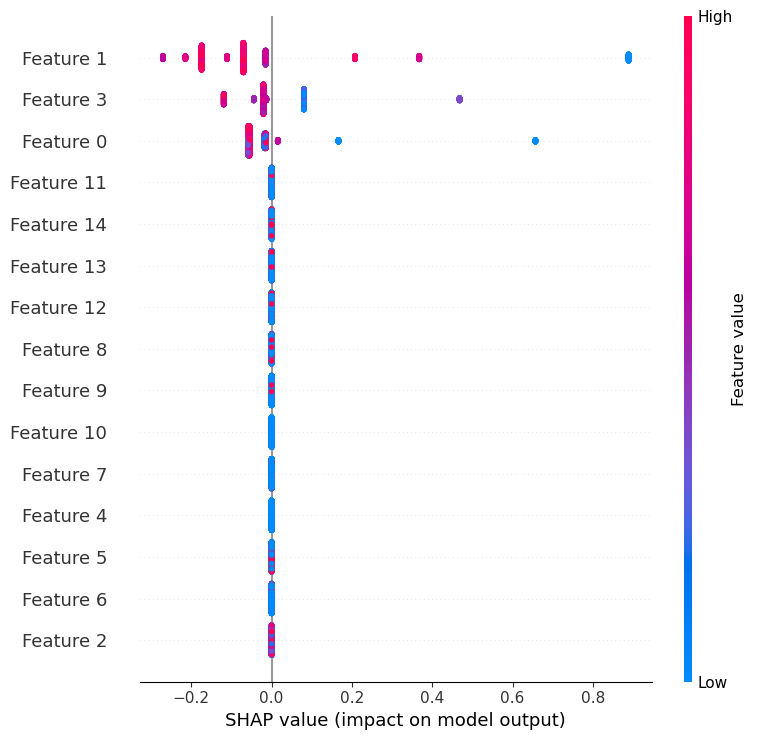

In [70]:
shap.summary_plot(shap_values[:, :, 1], X_train_processed)